# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression






## 1. Cargamos los datos

In [20]:
muebles = pd.read_csv('data\df_furniture.csv')
muebles.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jon\AppData\Local\Temp\ipykernel_19144\3659975230.py:1: SyntaxWarning: invalid escape sequence '\d'
  muebles = pd.read_csv('data\df_furniture.csv')


,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618


## 2. Tratar la fecha como texto e interpretar (parse)

In [21]:
muebles['Month'].isna().sum()

np.int64(5)

In [22]:
muebles = muebles.dropna(subset=['Month'])
muebles['Month'].isna().sum()


np.int64(0)

In [23]:
muebles['Month'] = muebles['Month'].astype(str)
muebles['Year'] = muebles['Month'].str[:4].astype(int)
muebles['Month_num'] = muebles['Month'].str[5:7].astype(int)
muebles['Day'] = muebles['Month'].str[8:10].astype(int)

muebles['Date'] = pd.to_datetime(
    muebles[['Year', 'Month_num', 'Day']].rename(
        columns={'Year': 'year', 'Month_num': 'month', 'Day': 'day'}
    )
)



## 3. ¿De qué fecha a qué fecha va el histórico?

In [24]:
fecha_inicio = muebles['Date'].min()
fecha_fin = muebles['Date'].max()

print(fecha_inicio)
print(fecha_fin)

1992-01-01 00:00:00
2019-07-01 00:00:00


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

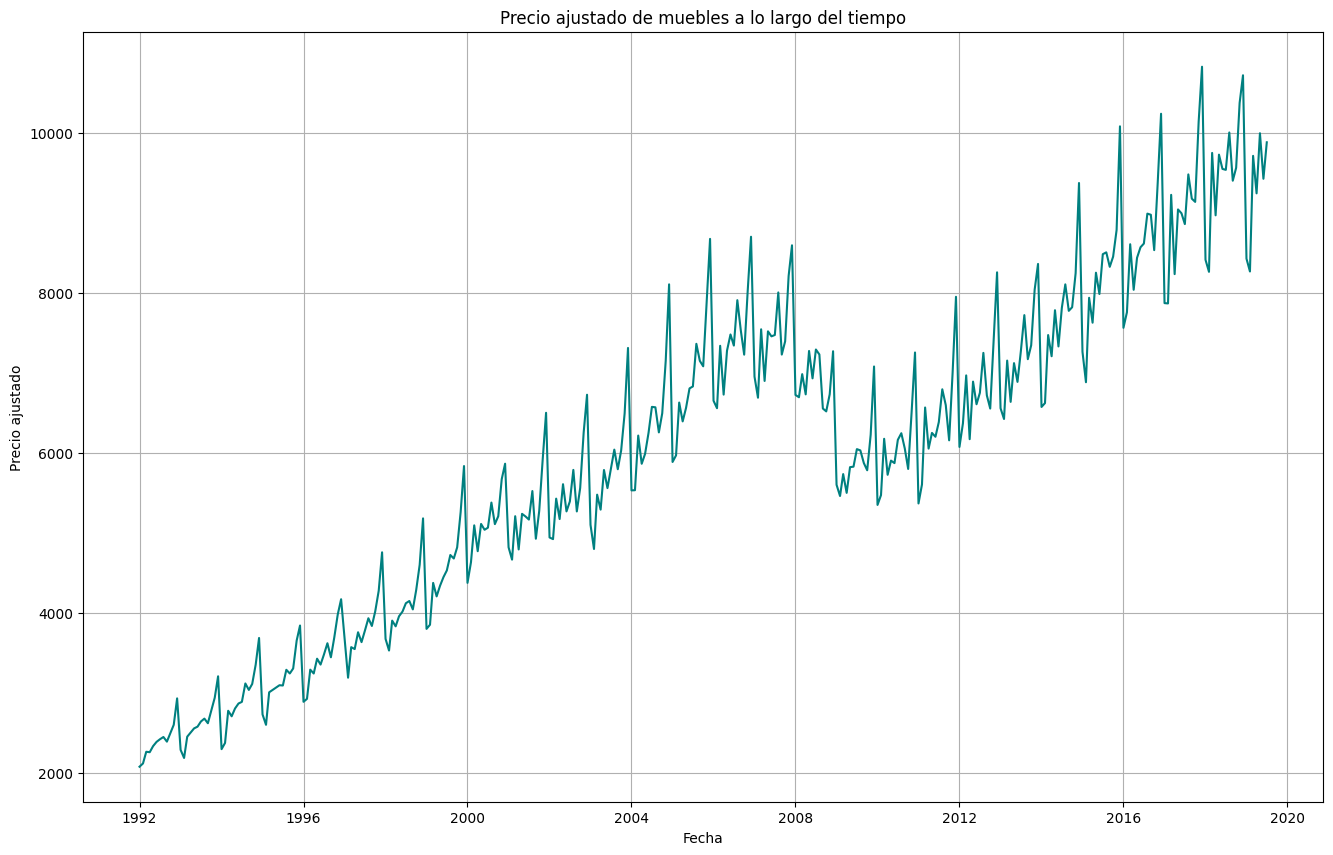

In [25]:
muebles.set_index('Date', inplace=True)

plt.figure(figsize=(16, 10))
plt.plot(muebles['furniture_price_adjusted'], color='teal')
plt.title('Precio ajustado de muebles a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Precio ajustado')
plt.grid(True)
plt.show()

La estacionalidad es recurrente año tras año, aunque podemos observar una gran dismunición de ventas a principios de años seguido de un gran aumento a finales, me atrevo a decir en los meses previos a Diciembre (Posible relación con el Black Friday?). Enero es el mes con una mayor caida de ventas y estas se van incrementando paulatinamente mes a mes con pequeñas caidas. 

Hay una clara tendencia postiva con un crecimiento se mantiene mayormente en todos los años, a excepcion del año 2008, la cual teniendo en cuenta en contexto economico podemos relacionarlo con un descenso de las ventas posiblemente asociado a la crisis economica de dicho año. Podemos deducir tambien a ojo que la serie es no-estacionaria ya que debido a esta tendencia su media y varianza va a cambiar a medida que pasa el tiempo.

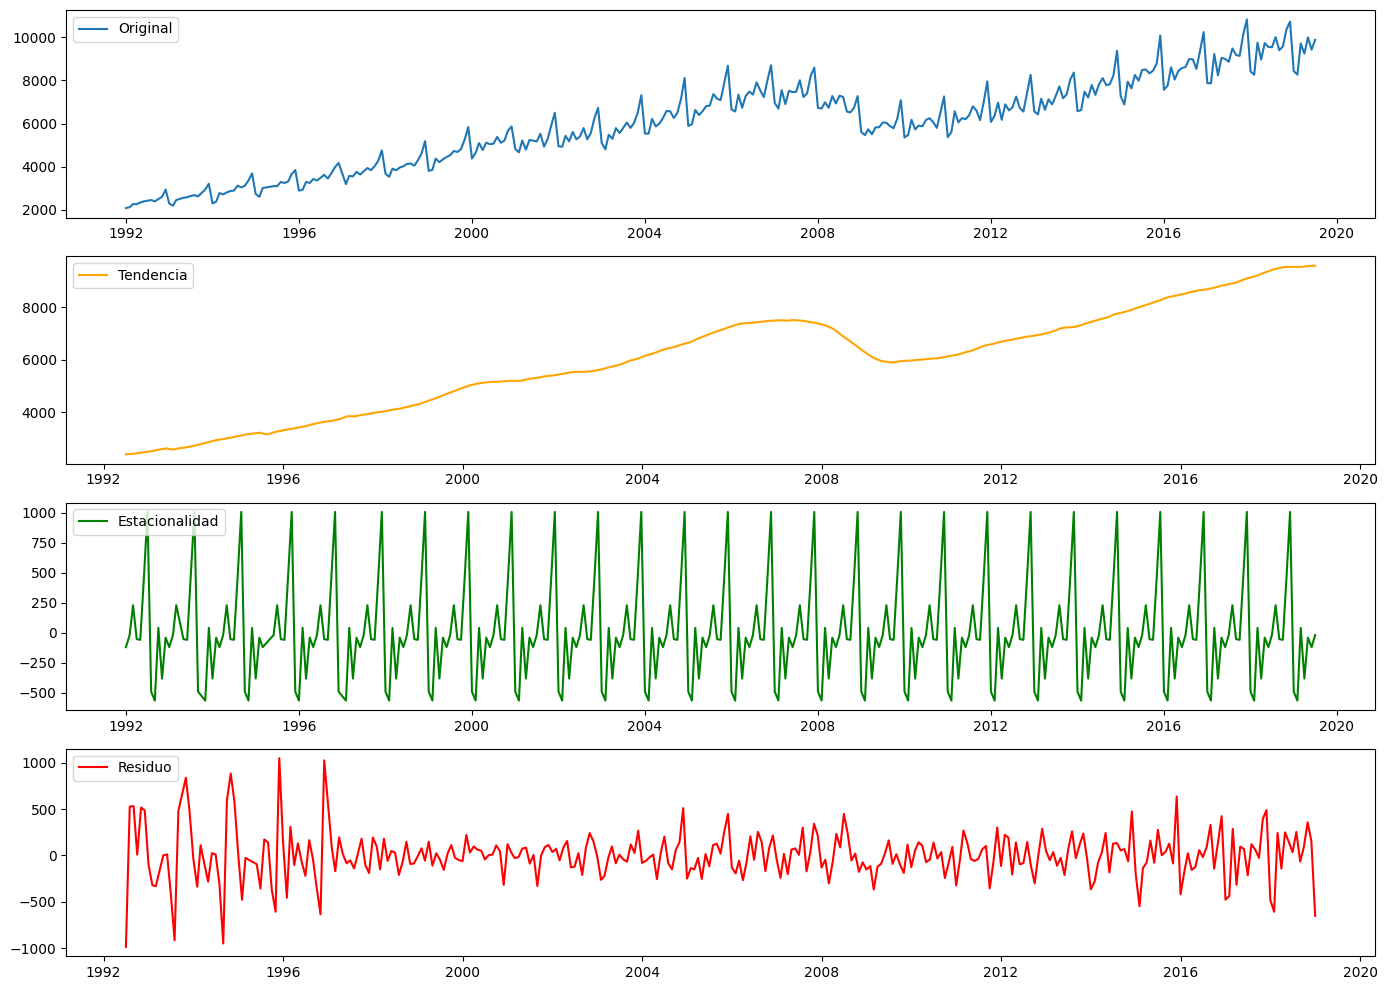

In [26]:
muebles_descomposicion = seasonal_decompose(muebles['furniture_price_adjusted'], model='additive', period=12)

plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(muebles_descomposicion.observed, label='Original')
plt.legend(loc='upper left')

plt.subplot(4, 1, 2)
plt.plot(muebles_descomposicion.trend, label='Tendencia', color='orange')
plt.legend(loc='upper left')

plt.subplot(4, 1, 3)
plt.plot(muebles_descomposicion.seasonal, label='Estacionalidad', color='green')
plt.legend(loc='upper left')

plt.subplot(4, 1, 4)
plt.plot(muebles_descomposicion.resid, label='Residuo', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [27]:

result = adfuller(muebles['furniture_price_adjusted'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.0947325476367464
p-value: 0.7171679263890343


In [28]:

result_kpss = kpss(muebles['furniture_price_adjusted'], regression='c', nlags='auto')
print('KPSS Statistic:', result_kpss[0])
print('p-value:', result_kpss[1])

KPSS Statistic: 2.5004435299414767
p-value: 0.01


C:\Users\Jon\AppData\Local\Temp\ipykernel_19144\4219788211.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(muebles['furniture_price_adjusted'], regression='c', nlags='auto')


El p-valor para ADF es muy alto (> 0.05), por lo que no rechazamos la hipótesis nula en que la serie tiene raíz unitaria, es decir, no es estacionaria. Por otro lado el KPSS, tiene como hipotesis nula de que la serie si que es estacionaria por lo que, al tener un valor de 0,01 rechazamos dicha H0, indicandonos que la no-estacionalidad de la serie. 

## 6. ¿Conoces algún método para representar mejor la tendencia?

Si, se va a emplear la media movil para visualizar la tendencia. Esto lo hacemos calculando la media de la serie en ventanas, en nuestro caso de 3 y 6 meses, de tal forma que asi suavizamos los picos y podemos ver la tendencia general de una forma aun mas clara. 

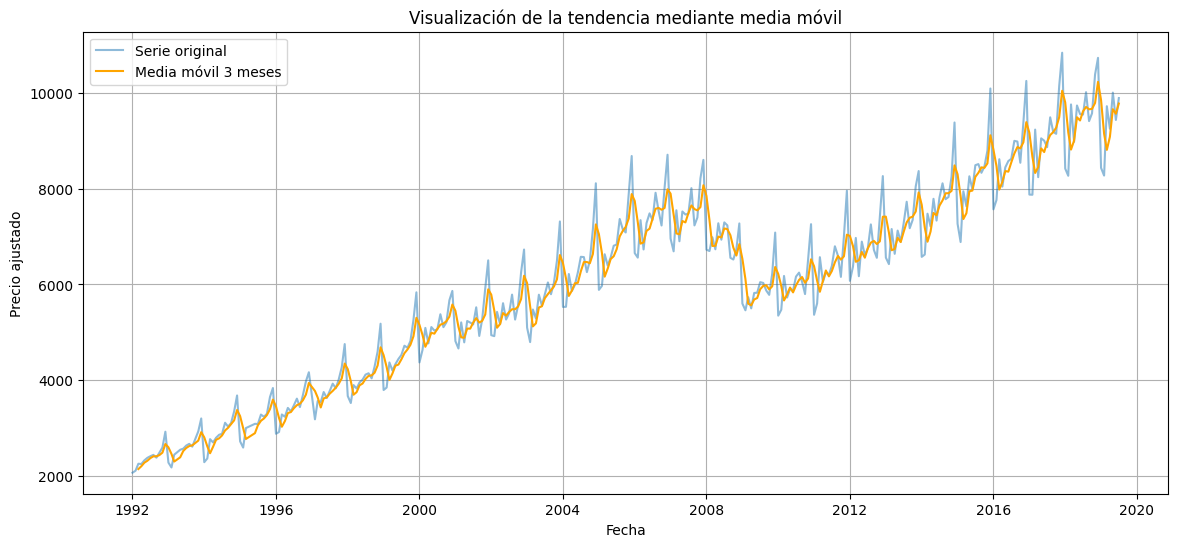

In [29]:
muebles['media_movil_3_meses'] = muebles['furniture_price_adjusted'].rolling(window=3).mean()

plt.figure(figsize=(14, 6))
plt.plot(muebles['furniture_price_adjusted'], label='Serie original', alpha=0.5)
plt.plot(muebles['media_movil_3_meses'], label='Media móvil 3 meses', color='orange')
plt.title('Visualización de la tendencia mediante media móvil')
plt.xlabel('Fecha')
plt.ylabel('Precio ajustado')
plt.legend()
plt.grid(True)
plt.show()

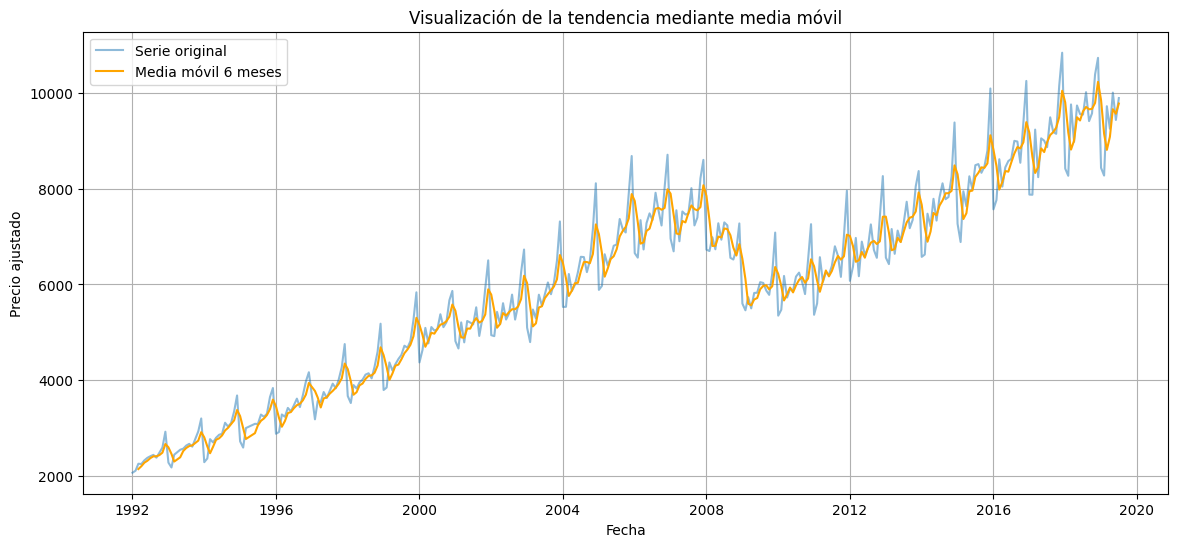

In [30]:
muebles['media_movil_6_meses'] = muebles['furniture_price_adjusted'].rolling(window=3).mean()

plt.figure(figsize=(14, 6))
plt.plot(muebles['furniture_price_adjusted'], label='Serie original', alpha=0.5)
plt.plot(muebles['media_movil_6_meses'], label='Media móvil 6 meses', color='orange')
plt.title('Visualización de la tendencia mediante media móvil')
plt.xlabel('Fecha')
plt.ylabel('Precio ajustado')
plt.legend()
plt.grid(True)
plt.show()

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

Hecho en el apartado 4.

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

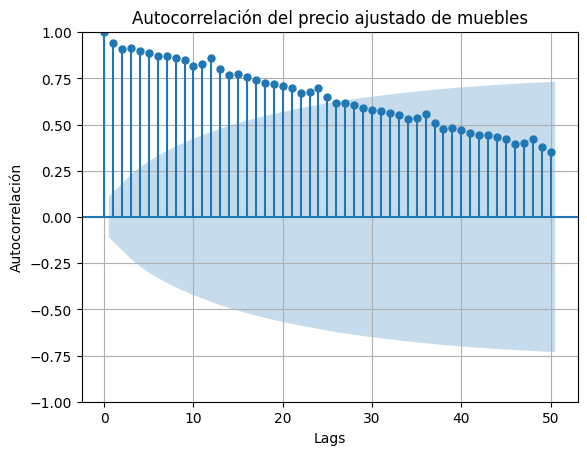

In [31]:
plot_acf(muebles['furniture_price_adjusted'], lags=50)
plt.title('Autocorrelación del precio ajustado de muebles')
plt.xlabel('Lags')
plt.ylabel('Autocorrelación')
plt.grid(True)
plt.show()

Los picos en los lags, 12, 24, 36 y 48 nos presenta una estacionalidad clara de carácter anual. 

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

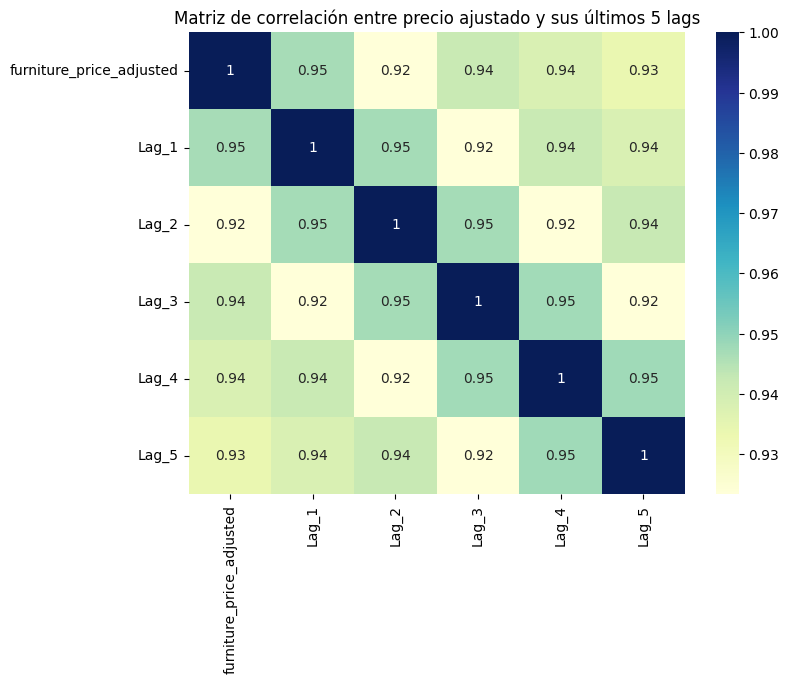

In [32]:
for i in range(1, 6):
    muebles[f'Lag_{i}'] = muebles['furniture_price_adjusted'].shift(i)

muebles_lags = muebles.dropna()
matriz_corr_lags5 = muebles_lags[['furniture_price_adjusted', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr_lags5, annot=True, cmap='YlGnBu')
plt.title('Matriz de correlación entre precio ajustado y sus últimos 5 lags')
plt.show()


## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

Como ya he demostrado en el gráfico del apartado 8, los picos se situan en los lags, 12,24,36 y 48, indicandonos una estacionalidad de 12 unidades (o un año)

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

Podemos hacerlo de diferentes formas, primero mediante diferenciación, es decir calculando la diferencia entre un valor y el valor anterior de tal forma que eliminamos la tendencia lineal. Si sigue sin ser estacionaria, podemos repetir este método hasta eliminar la tendencia por completo. Este es el mas adecuado si queremos emplear ARIMA mas adelante. 



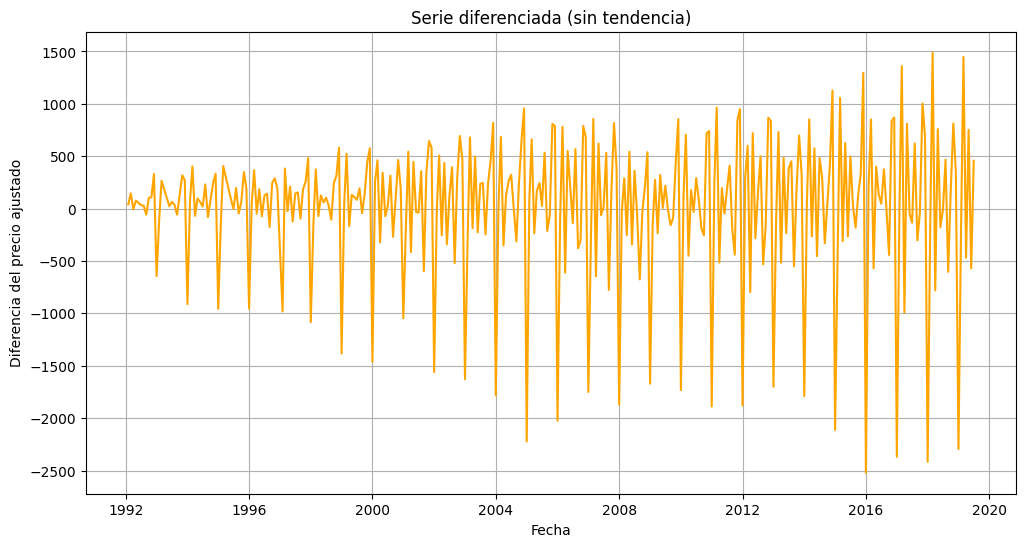

In [33]:
muebles['furniture_diferencia'] = muebles['furniture_price_adjusted'].diff()
muebles_diff = muebles.dropna(subset=['furniture_diferencia'])

plt.figure(figsize=(12, 6))
plt.plot(muebles_diff['furniture_diferencia'], color='orange')
plt.title('Serie diferenciada (sin tendencia)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia del precio ajustado')
plt.grid(True)
plt.show()


También podriamos eliminar la tendencia mediante ajustando la tendencia a una recta, todo ello mediante regresión lineal para luego restarla aloriginal. Quedandonos asi con la estacionalidad y el ruido. 

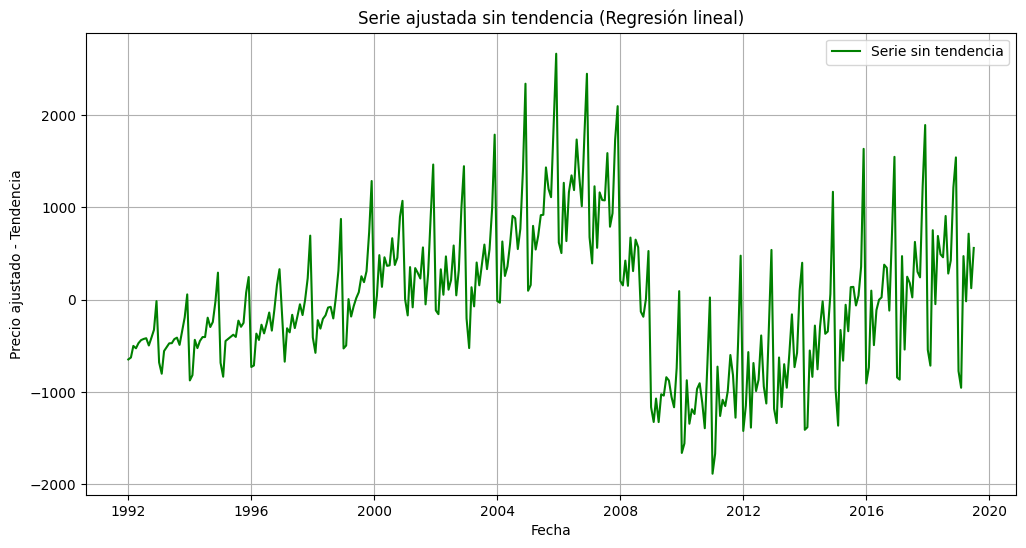

In [35]:
X = np.arange(len(muebles)).reshape(-1, 1)
y = muebles['furniture_price_adjusted'].values

modelo = LinearRegression()
modelo.fit(X, y)

tendencia_estimada = modelo.predict(X)
muebles['sin_tendencia'] = muebles['furniture_price_adjusted'] - tendencia_estimada

plt.figure(figsize=(12, 6))
plt.plot(muebles.index, muebles['sin_tendencia'], label='Serie sin tendencia', color='green')
plt.title('Serie ajustada sin tendencia (Regresión lineal)')
plt.xlabel('Fecha')
plt.ylabel('Precio ajustado - Tendencia')
plt.grid(True)
plt.legend()
plt.show()




Sin embargo como podemos ver la tendencia no desaparece del todo, esto se debe que en ocasiones una regresión lineal simple no capta toda la estructura en su totalidad, ya que el tipo de tendencia puede ser mas curva (cuadratica, exponencial o logaritmica por citar algunos ejemplo ), y los residuos que obtenemos pueden demostrar todavia esa tendencia. 